# AICE Associate 실전 연습 - DAY 16-2

## 고객 문의 우선순위 예측

- 도메인: 고객 서비스 운영
- 목표: 고객 문의 데이터를 이용해 문의 처리 우선순위 `priority`를 예측하는 인공지능 모델 개발
- 데이터 파일: `aice_customer_support_priority.csv`

### 유의사항

- 답안은 각 문항 바로 아래의 지정된 코드 셀에 작성합니다.
- 문항에서 지정한 변수명을 그대로 사용합니다.
- 기존 문제 셀은 삭제하지 않습니다.
- 데이터 파일과 이 노트북을 같은 폴더에 둡니다.


## 데이터 컬럼 설명

| 컬럼 | 설명 |
|---|---|
| ticket_id | 문의 식별번호 |
| created_at | 문의 접수일시 |
| customer_age | 고객 나이 |
| membership_tier | 회원 등급 |
| issue_type | 문의 유형 |
| contact_channel | 문의 채널 |
| region | 고객 지역 |
| monthly_spend | 월평균 이용금액 |
| tenure_months | 가입 기간 |
| previous_tickets | 과거 문의 횟수 |
| avg_response_minutes | 평균 응답 대기시간 |
| satisfaction_score | 만족도 점수 |
| reopened_count | 문의 재접수 횟수 |
| resolution_hours | 문의 해결 시간 |
| priority | 문의 우선순위: Low, Medium, High |


# 데이터 분석

## 1. 라이브러리 불러오기

다음 라이브러리를 지정된 별칭으로 불러오세요.

- pandas: `pd`
- numpy: `np`
- seaborn: `sns`
- matplotlib.pyplot: `plt`


In [1]:
# 여기에 답안 코드를 작성하고 실행하세요.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. 데이터 불러오기

- `aice_customer_support_priority.csv`를 불러오세요.
- 데이터프레임 변수명은 `data`로 지정하세요.
- 처음 4개 행을 출력하세요.


In [2]:
# 여기에 답안 코드를 작성하고 실행하세요.
data = pd.read_csv('aice_customer_support_priority.csv')

data.head(4)

,ticket_id,created_at,customer_age,membership_tier,issue_type,contact_channel,region,monthly_spend,tenure_months,previous_tickets,avg_response_minutes,satisfaction_score,reopened_count,resolution_hours,priority
0,TK-260000,2025-10-02 12:00:00,21,Gold,Delivery,Email,Seoul,158405.0,51,0,74,2.8,1,4.5,High
1,TK-260001,2026-01-31 00:00:00,24,Silver,Payment,Chat,Busan,88777.0,8,7,62,3.3,0,4.6,Medium
2,TK-260002,2025-05-24 14:00:00,51,Silver,Payment,Chat,Busan,72751.0,45,1,14,4.4,0,14.4,Medium
3,TK-260003,2026-03-15 02:00:00,47,VIP,Payment,Chat,Incheon,223965.0,65,3,56,4.9,3,6.1,Medium


## 3. 데이터 기본정보 확인

다음을 확인하세요.

- 행과 열 개수
- 컬럼별 자료형
- 컬럼별 결측치 개수
- `priority`의 범주별 개수


In [3]:
# 여기에 답안 코드를 작성하고 실행하세요.
print(data.shape)
print(data.dtypes)
print(data.isnull().sum())
print(data['priority'].value_counts())

(1500, 15)
ticket_id                   str
created_at                  str
customer_age              int64
membership_tier             str
issue_type                  str
contact_channel             str
region                      str
monthly_spend           float64
tenure_months             int64
previous_tickets          int64
avg_response_minutes      int64
satisfaction_score      float64
reopened_count            int64
resolution_hours        float64
priority                    str
dtype: object
ticket_id                0
created_at               0
customer_age             0
membership_tier          0
issue_type               0
contact_channel         16
region                   0
monthly_spend           24
tenure_months            0
previous_tickets         0
avg_response_minutes     0
satisfaction_score      19
reopened_count           0
resolution_hours         0
priority                 0
dtype: int64
priority
Medium    859
Low       449
High      192
Name: count, dtype: int64


## 4. 두 그래프를 나란히 시각화

- `subplots`를 사용해 그래프 2개를 가로로 배치하세요.
- 전체 크기는 `(15, 6)`입니다.
- 왼쪽: `issue_type`의 countplot, 제목 `Issue Count`
- 오른쪽: `priority`별 `satisfaction_score`의 histplot, 제목 `Satisfaction Distribution`
- 왼쪽 X축 눈금을 45도 회전하세요.

아래 코드의 빈칸을 채우고 실행하세요.


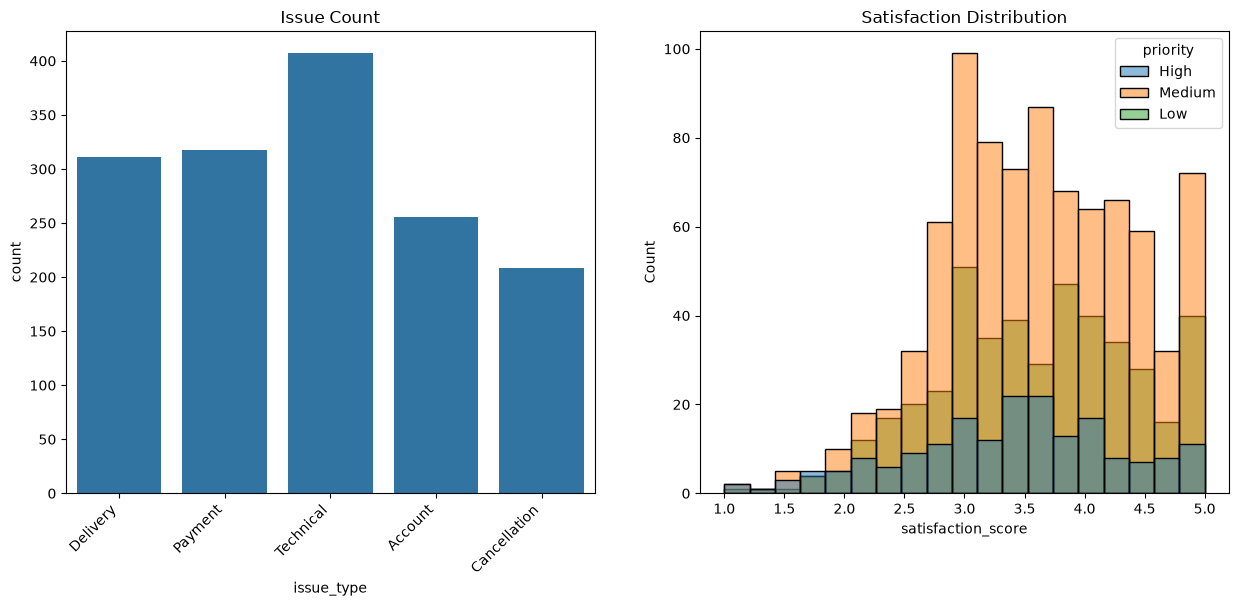

In [4]:
# 추가 학습 필요
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

sns.countplot(data=data, x='issue_type', ax=axes[0])
sns.histplot(data=data, x='satisfaction_score', hue='priority', ax=axes[1])

plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

axes[0].set_title('Issue Count')
axes[1].set_title('Satisfaction Distribution')

plt.show()


## 5. Boxplot 시각화

`priority`별 `avg_response_minutes`의 분포를 boxplot으로 표현하세요.

- X축: `priority`
- Y축: `avg_response_minutes`


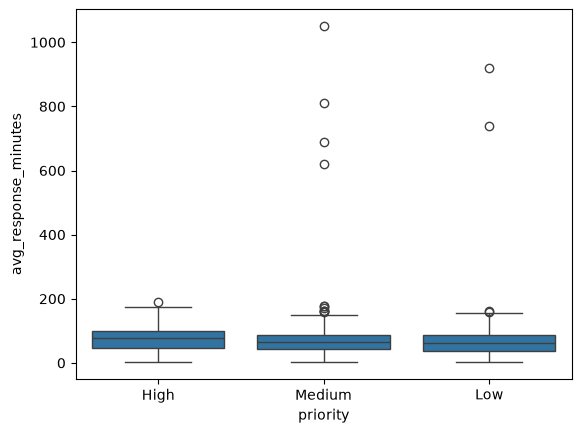

In [5]:
# 여기에 답안 코드를 작성하고 실행하세요.
sns.boxplot(data=data, x='priority', y='avg_response_minutes')
plt.show()

# 데이터 전처리

## 6. 날짜 파생변수 생성

- `created_at`을 날짜 자료형으로 변환하세요.
- `created_year`, `created_month`, `created_dayofweek`, `created_hour`를 생성하세요.
- 기존 `created_at` 컬럼을 삭제하세요.
- 처리 결과는 기존 `data`에 반영하세요.


In [6]:
# 여기에 답안 코드를 작성하고 실행하세요.
data['created_at'] = pd.to_datetime(data['created_at'])

data['created_year'] = data['created_at'].dt.year
data['created_month'] = data['created_at'].dt.month
data['created_dayofweek'] = data['created_at'].dt.dayofweek
data['created_hour'] = data['created_at'].dt.hour

data.drop(columns=['created_at'], inplace=True)

## 7. 이상치와 불필요한 컬럼 처리

- `avg_response_minutes`의 IQR 정상 범위를 계산하세요.
- 정상 범위에 포함된 행만 선택하세요.
- `ticket_id`를 삭제하세요.
- 결과는 `data_temp`에 저장하세요.
- 인덱스를 초기화하세요.

아래 코드에는 오류가 있습니다. 수정하고 실행하세요.


In [7]:
q1 = data['avg_response_minutes'].quantile(0.25)
q3 = data['avg_response_minutes'].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

data_temp = data[
    (data['avg_response_minutes'] >= lower_fence)
    & (data['avg_response_minutes'] <= upper_fence)
]

data_temp = data_temp.drop(columns=['ticket_id'])
data_temp.reset_index(drop=True, inplace=True)


## 8. 결측치 처리

- 수치형 컬럼의 결측치는 해당 컬럼의 중앙값으로 대체하세요.
- 범주형 컬럼의 결측치는 해당 컬럼의 최빈값으로 대체하세요.
- 결과는 `data_na`에 저장하세요.
- 처리 후 컬럼별 결측치 개수를 확인하세요.


In [8]:
# 여기에 답안 코드를 작성하고 실행하세요.
data_temp['contact_channel'] = data_temp['contact_channel'].fillna(data_temp['contact_channel'].mode()[0])

data_temp['monthly_spend'] = data_temp['monthly_spend'].fillna(data_temp['monthly_spend'].median())

data_temp['satisfaction_score'] = data_temp['satisfaction_score'].fillna(data_temp['satisfaction_score'].median())

data_na = data_temp.copy()
data_na.isnull().sum()

customer_age            0
membership_tier         0
issue_type              0
contact_channel         0
region                  0
monthly_spend           0
tenure_months           0
previous_tickets        0
avg_response_minutes    0
satisfaction_score      0
reopened_count          0
resolution_hours        0
priority                0
created_year            0
created_month           0
created_dayofweek       0
created_hour            0
dtype: int64

## 9. 범주 통합

`issue_type`의 `Payment`, `Account`를 모두 `Account/Billing`으로 변경하세요.

- `isin()`과 `loc[]`를 사용하세요.
- 변경 후 범주별 개수를 출력하세요.


In [9]:
# 여기에 답안 코드를 작성하고 실행하세요.
# 추가 학습 필요 isin 및 해당 방식
data_na.loc[
    data_na['issue_type'].isin(['Payment', 'Account']),
    'issue_type'
] = 'Account/Billing'

data_na['issue_type'].value_counts()

issue_type
Account/Billing    571
Technical          398
Delivery           309
Cancellation       200
Name: count, dtype: int64

## 10. 타깃 라벨 인코딩

- `LabelEncoder` 객체를 `le`에 저장하세요.
- `priority`를 정수 라벨로 변환해 기존 컬럼에 저장하세요.
- `le.classes_`로 클래스와 숫자의 대응 관계를 확인하세요.


In [10]:
# 여기에 답안 코드를 작성하고 실행하세요.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data_na['priority'] = le.fit_transform(data_na['priority'])

le.classes_

array(['High', 'Low', 'Medium'], dtype=object)

## 11. 원-핫 인코딩

다음 컬럼을 원-핫 인코딩하세요.

- `membership_tier`
- `issue_type`
- `contact_channel`
- `region`

조건:

- 첫 번째 범주 제거
- 더미변수는 정수형
- 결과 변수명은 `data_preset`
- `info()`로 결과 확인


In [11]:
# 여기에 답안 코드를 작성하고 실행하세요.
data_na = pd.get_dummies(data_na , columns=['membership_tier', 'issue_type', 'contact_channel', 'region'], drop_first=True, dtype=int)

data_na.info()

<class 'pandas.DataFrame'>
RangeIndex: 1478 entries, 0 to 1477
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_age             1478 non-null   int64  
 1   monthly_spend            1478 non-null   float64
 2   tenure_months            1478 non-null   int64  
 3   previous_tickets         1478 non-null   int64  
 4   avg_response_minutes     1478 non-null   int64  
 5   satisfaction_score       1478 non-null   float64
 6   reopened_count           1478 non-null   int64  
 7   resolution_hours         1478 non-null   float64
 8   priority                 1478 non-null   int64  
 9   created_year             1478 non-null   int32  
 10  created_month            1478 non-null   int32  
 11  created_dayofweek        1478 non-null   int32  
 12  created_hour             1478 non-null   int32  
 13  membership_tier_Gold     1478 non-null   int64  
 14  membership_tier_Silver   1478 non-n

# 데이터 분리 및 스케일링

## 12. 독립변수와 종속변수 분리

- 독립변수: `X`
- 종속변수: `y`
- 종속변수 컬럼: `priority`


In [12]:
# 여기에 답안 코드를 작성하고 실행하세요.
x = data_na.drop(columns=['priority'])
y = data_na['priority']

x.head()

,customer_age,monthly_spend,tenure_months,previous_tickets,avg_response_minutes,satisfaction_score,reopened_count,resolution_hours,created_year,created_month,...,issue_type_Cancellation,issue_type_Delivery,issue_type_Technical,contact_channel_Chat,contact_channel_Email,contact_channel_Phone,region_Daegu,region_Daejeon,region_Incheon,region_Seoul
0,21,158405.0,51,0,74,2.8,1,4.5,2025,10,...,0,1,0,0,1,0,0,0,0,1
1,24,88777.0,8,7,62,3.3,0,4.6,2026,1,...,0,0,0,1,0,0,0,0,0,0
2,51,72751.0,45,1,14,4.4,0,14.4,2025,5,...,0,0,0,1,0,0,0,0,0,0
3,47,223965.0,65,3,56,4.9,3,6.1,2026,3,...,0,0,0,1,0,0,0,0,1,0
4,32,96114.0,11,2,57,2.6,1,9.2,2025,8,...,0,0,1,0,1,0,0,0,0,1


## 13. 훈련·검증 데이터 분리

- 훈련:검증 비율은 80:20입니다.
- 난수 시드는 `42`입니다.
- 클래스 비율을 유지하세요.
- 변수명은 `X_train`, `X_valid`, `y_train`, `y_valid`로 지정하세요.


In [13]:
# 여기에 답안 코드를 작성하고 실행하세요.
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 14. StandardScaler 적용

- 훈련 데이터에서 스케일링 기준을 학습하세요.
- 검증 데이터에는 훈련 데이터의 기준만 적용하세요.
- 스케일링된 훈련 데이터 전체 평균을 소수점 둘째 자리까지 출력하세요.

아래 코드에는 오류가 있습니다. 수정하고 실행하세요.


In [14]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)
X_valid_scaled = ss.transform(X_valid)

print(round(np.mean(X_train_scaled), 2))


-0.0


# 머신러닝 모델링

## 15. RandomForest 모델 학습

다음 조건으로 `RandomForestClassifier`를 생성하고 학습하세요.

- 모델 변수명: `rf`
- `n_estimators=200`
- `max_depth=8`
- `min_samples_split=5`
- `random_state=42`
- 스케일링된 훈련 데이터 사용


In [15]:
# 여기에 답안 코드를 작성하고 실행하세요.
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train_scaled, y_train);

## 16. RandomForest 평가

- 검증 데이터 예측 결과를 `y_pred_rf`에 저장하세요.
- Accuracy를 출력하세요.
- Confusion Matrix를 출력하세요.
- Classification Report를 출력하세요.


In [16]:
# 여기에 답안 코드를 작성하고 실행하세요.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_rf = rf.predict(X_valid_scaled)

print(accuracy_score(y_valid, y_pred_rf))
print(confusion_matrix(y_valid, y_pred_rf))
print(classification_report(y_valid, y_pred_rf))

0.5743243243243243
[[  0   0  37]
 [  0   2  87]
 [  0   2 168]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        37
           1       0.50      0.02      0.04        89
           2       0.58      0.99      0.73       170

    accuracy                           0.57       296
   macro avg       0.36      0.34      0.26       296
weighted avg       0.48      0.57      0.43       296



c:\Users\LSG\Desktop\AICE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LSG\Desktop\AICE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LSG\Desktop\AICE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 17. 변수 중요도

- 변수명과 중요도를 DataFrame으로 생성하세요.
- 컬럼명은 `feature`, `importance`로 지정하세요.
- 중요도 내림차순 상위 10개를 선택하세요.
- barplot으로 시각화하세요.
- 가장 중요도가 높은 변수명을 확인하세요.

아래 코드에는 오류가 있습니다. 수정하고 실행하세요.


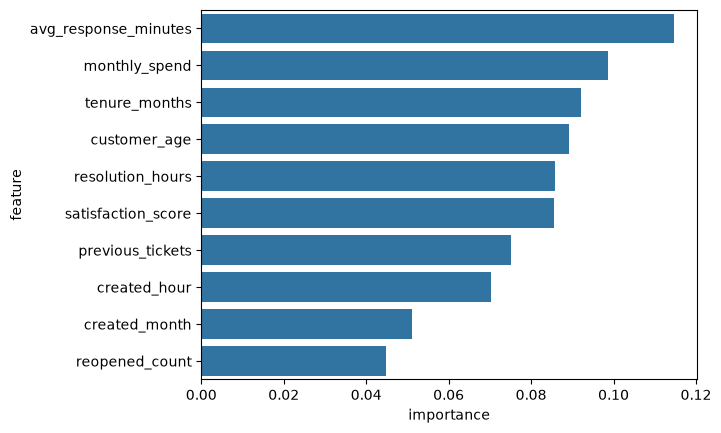

In [17]:
fi = pd.DataFrame({
    'feature': x.columns,
    'importance': rf.feature_importances_
})

# 내림차순 상위 10개 
fi = fi.sort_values('importance', ascending=False).head(10)

sns.barplot(data=fi, x='importance', y='feature')
plt.show()


# 딥러닝 모델링

다음 코드를 먼저 실행하세요.


In [18]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)


## 18. 클래스 개수 계산

`y_train`의 고유한 클래스 개수를 계산해 `num_classes`에 저장하세요.


In [19]:
# 여기에 답안 코드를 작성하고 실행하세요.
num_classes = len(np.unique(y_train))

## 19. 다중분류 딥러닝 모델 생성

모델 변수명은 `model`로 지정하고 다음 구조로 생성하세요.

1. Input: 입력 변수 개수
2. Dense: 노드 64개, `relu`
3. Dropout: 비율 0.2
4. Dense: 노드 32개, `relu`
5. Dense: 노드 수 `num_classes`, `softmax`


In [20]:
# 여기에 답안 코드를 작성하고 실행하세요.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

## 20. EarlyStopping 설정

다음 조건으로 EarlyStopping을 생성해 `estop`에 저장하세요.

- 모니터링 지표: `val_loss`
- patience: 8
- 가장 성능이 좋았던 가중치 복원


In [21]:
# 여기에 답안 코드를 작성하고 실행하세요.
from tensorflow.keras.callbacks import EarlyStopping

estop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

## 21. 모델 컴파일

현재 타깃은 정수 라벨입니다. 다음 조건으로 컴파일하세요.

- optimizer: `adam`
- loss: `sparse_categorical_crossentropy`
- metrics: `accuracy`

이 문항에서는 `to_categorical()`을 사용하지 않습니다.


In [22]:
# 여기에 답안 코드를 작성하고 실행하세요.
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 22. 모델 학습

- 학습 정보 변수명: `history`
- epochs: 50
- batch_size: 64
- 검증 데이터: `X_valid_scaled`, `y_valid`
- callbacks: `estop`
- 안내된 내용 외 별도 파라미터를 사용하지 마세요.


In [23]:
# 여기에 답안 코드를 작성하고 실행하세요.
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_valid_scaled, y_valid), # 추가 학습 필요
    callbacks=[estop]
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4602 - loss: 1.0618 - val_accuracy: 0.5676 - val_loss: 0.9715
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5533 - loss: 0.9752 - val_accuracy: 0.5811 - val_loss: 0.9482
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5677 - loss: 0.9477 - val_accuracy: 0.5642 - val_loss: 0.9320
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5668 - loss: 0.9341 - val_accuracy: 0.5642 - val_loss: 0.9234
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5626 - loss: 0.9176 - val_accuracy: 0.5642 - val_loss: 0.9173
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5668 - loss: 0.9100 - val_accuracy: 0.5608 - val_loss: 0.9126
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5728 - loss: 0.8886 - val_accuracy: 0.5608 - val_loss: 0.9088
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5888 - loss: 0.8916 - val_accuracy: 0.5541 - val_loss

## 23. 딥러닝 모델 평가

- `model.evaluate()`를 사용하세요.
- 검증 Loss와 Accuracy를 각각 `dl_loss`, `dl_accuracy`에 저장하세요.
- 두 값을 출력하세요.


In [24]:
# 여기에 답안 코드를 작성하고 실행하세요.
dl_loss, dl_accuracy = model.evaluate(
    X_valid_scaled,
    y_valid
)

print(dl_loss)
print(dl_accuracy)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5709 - loss: 0.8988 
0.8988026976585388
0.5709459185600281


## 24. 클래스 예측

- 예측 확률을 `y_proba_dl`에 저장하세요.
- `np.argmax()`를 사용해 최종 클래스를 `y_pred_dl`에 저장하세요.
- Confusion Matrix와 Classification Report를 출력하세요.


In [25]:
# 여기에 답안 코드를 작성하고 실행하세요.
# 복습 필요
y_proba_dl = model.predict(X_valid_scaled)

y_pred_dl = np.argmax(y_proba_dl, axis=1)

print(confusion_matrix(y_valid, y_pred_dl))
print(classification_report(y_valid, y_pred_dl))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[[  2   2  33]
 [  2  13  74]
 [  3  13 154]]
              precision    recall  f1-score   support

           0       0.29      0.05      0.09        37
           1       0.46      0.15      0.22        89
           2       0.59      0.91      0.71       170

    accuracy                           0.57       296
   macro avg       0.45      0.37      0.34       296
weighted avg       0.51      0.57      0.49       296



## 25. 학습 과정 시각화

하나의 그래프에 훈련 Accuracy와 검증 Accuracy를 표현하세요.

- 범례: `acc`, `val_acc`
- 제목: `Model Accuracy`
- X축: `Epochs`
- Y축: `Accuracy`


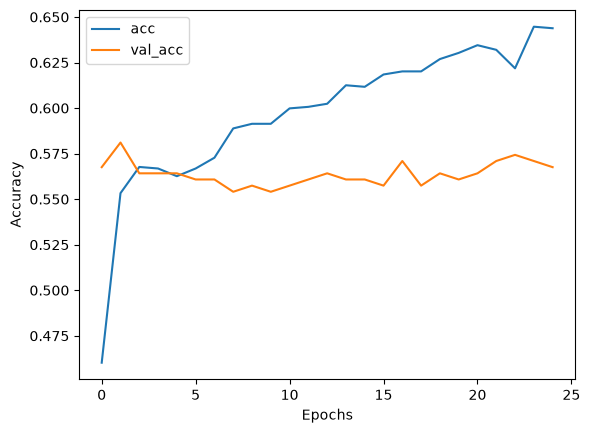

In [ ]:
# 여기에 답안 코드를 작성하고 실행하세요.
# 복습 필요
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

---

모든 문항을 완료한 뒤 커널을 재시작하고 전체 셀을 순서대로 실행하세요.
